# 04. ε-greedy 밴디트 알고리즘

앞에서 구현한 `Bandit`은 선택한 머신의 보상을 생성하고, `Agent`는 ε-greedy 행동 선택과 표본평균 값의 갱신을 수행한다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from bandit import Bandit, Agent
plt.rcParams['font.family'] = 'AppleGothic'   # macOS

plt.rcParams['axes.unicode_minus'] = False

rng = np.random.default_rng(22)

## 행동 선택 → 보상 관측 → 가치 갱신

전체 시행 횟수는 $N$, 현재까지 플레이한 횟수는 $n$으로 표시한다. 반복문은 $n=1,2,\ldots,N$ 순서로 진행한다. $N_n(a)$는 전체 $n$번 중 머신 $a$를 선택한 횟수이며, 코드의 `agent.ns[a]`에 해당한다.

### 반복문 

1. `agent.get_action()`: ε-greedy로 슬롯머신을 선택한다.
2. `bandit.play(action)`: 선택한 슬롯머신의 보상을 받는다.
3. `agent.update(action, reward)`: 해당 슬롯머신의 관측 횟수와 추정치를 갱신한다.
4. 누적 보상, 평균 보상, 슬롯머신별 추정치를 기록한다.



In [2]:
# 시도 횟수 지정 
N = 1000

# 무작위로 슬롯머신를 선택할 확률을 지정 
epsilon = 0.1

# 슬롯머신 수 지정 
K = 10

# 인스턴스 만들기
bandit = Bandit(K)
agent = Agent(epsilon, K)

# 총 보상 초기화 
total_reward = 0

# 기록용 목록 초기화
total_rewards = []
rates=[]
all_rates = np.zeros((K, N+ 1 ))

# 초기값 기록 
all_rates[:, 0 ] = agent.Qs

# 반복 시도 
for n in range(1, N + 1):
     # ε-greedy법으로 플레이할 슬롯머신 번호를 결정
    action = agent.get_action()
    
    # action번째 슬롯머신 플레이
    reward = bandit.play(action)
    
    # action 번째 슬롯머신의 예상 가치 업데이트
    agent.update(action, reward)
    
    # 보상 추가
    total_reward +=reward
    
    # 업데이트 값 기록
    total_rewards.append(total_reward)
    rates.append(total_reward / n)
    all_rates[:, n] = agent.Qs

# 최종 결과 확인 
print (total_reward)
print (rates[N- 1 ])

853
0.853


## 3. 누적 보상과 평균 보상

$n$번 플레이한 뒤의 누적 보상 $C_n$와 평균 보상 $\bar R_n$는 다음과 같다.

$$C_n=\sum_{i=1}^{n}R_i,\qquad \bar R_n=\frac{C_n}{n}.$$



findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


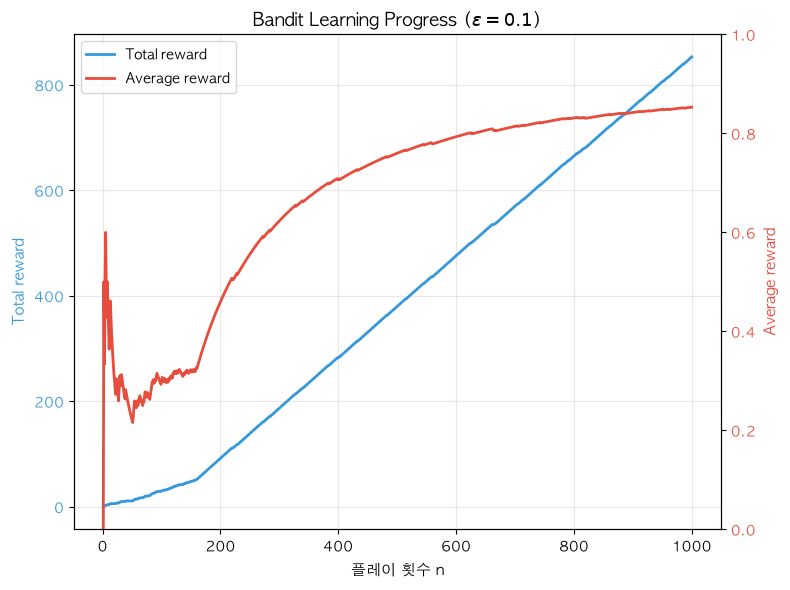

In [3]:

fig, ax_left = plt.subplots(figsize=(8, 6))
ax_right = ax_left.twinx()

x = np.arange(1, N + 1)

# 왼쪽 y축: 누적 보상
line1, = ax_left.plot(x, total_rewards, label='Total reward', 
                      color='#3498db', linewidth=2)
ax_left.set_xlabel('플레이 횟수 n', fontsize=11)
ax_left.set_ylabel('Total reward', color='#3498db', fontsize=11)
ax_left.tick_params(axis='y', labelcolor='#3498db')
ax_left.grid(alpha=0.3)

# 오른쪽 y축: 평균 보상
line2, = ax_right.plot(x, rates, label='Average reward', 
                       color='#e74c3c', linewidth=2)
ax_right.set_ylabel('Average reward', color='#e74c3c', fontsize=11)
ax_right.tick_params(axis='y', labelcolor='#e74c3c')
ax_right.set_ylim(0, 1)

# 범례
ax_left.legend(handles=[line1, line2], loc='upper left', fontsize=10)

# 제목
ax_left.set_title(f'Bandit Learning Progress ($\\epsilon={epsilon}$)', 
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


## 머신별 행동 가치 추정치의 변화


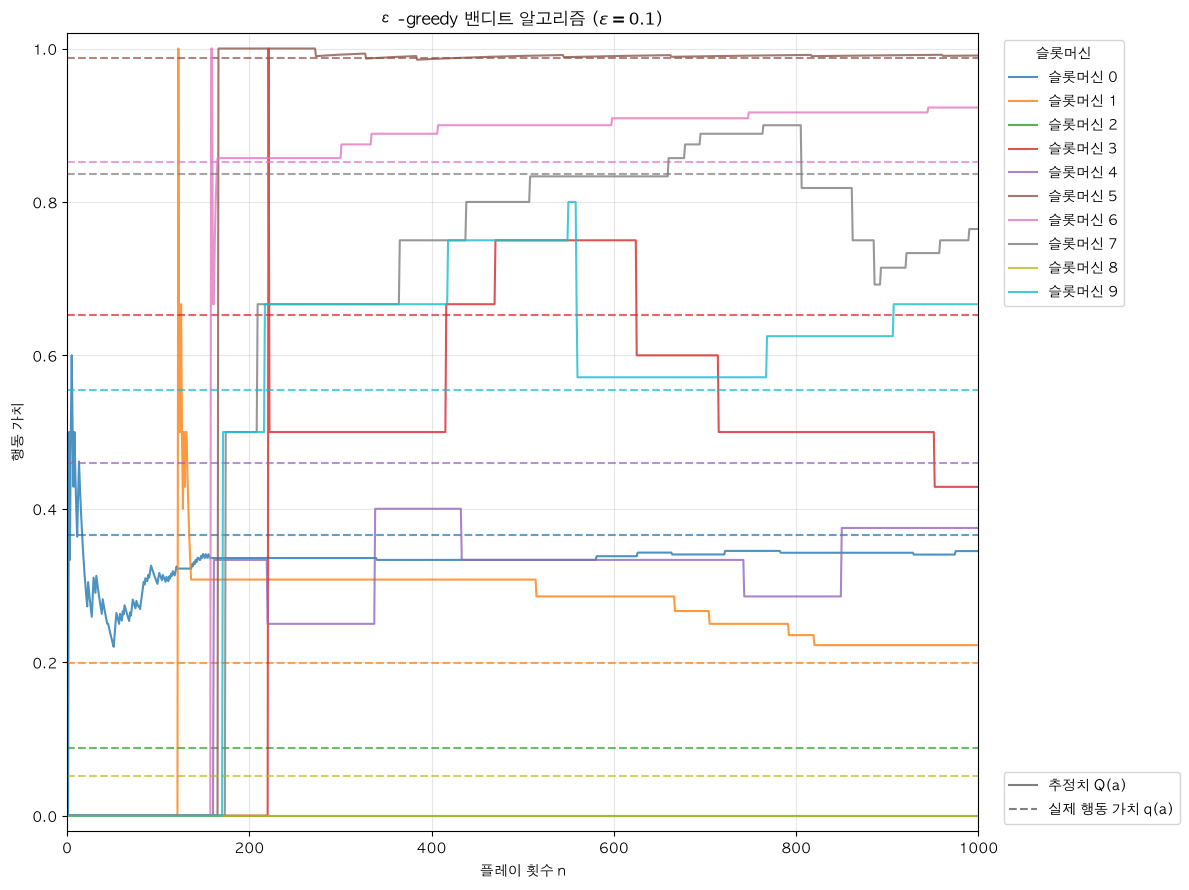

In [4]:
from matplotlib.lines import Line2D

cm = plt.get_cmap('tab10')
fig, ax = plt.subplots(figsize=(12, 9))
x = np.arange(N + 1)

for arm in range(K):
    color = cm(arm % cm.N)
    # 실선: 관측한 보상으로 갱신한 행동 가치 추정치
    ax.plot(x, all_rates[arm], color=color, linewidth=1.5,
            alpha=0.8, label=f"슬롯머신 {arm}")
    # 점선: 해당 머신의 실제 행동 가치 (목표값)
    ax.axhline(bandit.rates[arm], color=color, linestyle='--',
               linewidth=1.5, alpha=0.7)

ax.set_xlabel('플레이 횟수 n')
ax.set_ylabel('행동 가치')
ax.set_title(rf'ε-greedy 밴디트 알고리즘 ($\epsilon={epsilon}$)')
ax.set_xlim(0, N)
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.3)

# 색은 머신을, 선 모양은 실제 값과 추정치를 구분한다.
machine_legend = ax.legend(title='슬롯머신', loc='upper left',
                           bbox_to_anchor=(1.02, 1))
ax.add_artist(machine_legend)
ax.legend(handles=[
    Line2D([0], [0], color='gray', linestyle='-',
           label='추정치 Q(a)'),
    Line2D([0], [0], color='gray', linestyle='--',
           label='실제 행동 가치 q(a)')
], loc='lower left', bbox_to_anchor=(1.02, 0))

plt.tight_layout()
plt.show()


## 실제 행동 가치와 추정치 비교


In [5]:
# 실제 행동 가치 확인 
print (np.round(bandit.rates, 3 ))

# 추정 가치 확인 
print (np.round(agent.Qs, 3 ))

[0.366 0.199 0.089 0.653 0.459 0.988 0.852 0.837 0.051 0.555]
[0.345 0.222 0.    0.429 0.375 0.991 0.923 0.765 0.    0.667]


## 최종결과 


In [6]:
print(f"각 슬롯머신의 선택 횟수 = {agent.ns}")
print(f"실제 행동 가치가 가장 큰 슬롯머신 번호 = {np.argmax(bandit.rates)}")
print(f"최대 선택 슬롯머신 = {np.argmax(agent.ns)}")
print(f"실제 행동 가치의 최대값  = {np.max(bandit.rates)}")
print(f"전체 평균 보상 = {rates[-1]:.3f}")

각 슬롯머신의 선택 횟수 = [145.  18.   5.   7.   8. 769.  13.  17.   9.   9.]
실제 행동 가치가 가장 큰 슬롯머신 번호 = 5
최대 선택 슬롯머신 = 5
실제 행동 가치의 최대값  = 0.9876756188802016
전체 평균 보상 = 0.853
